In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

import sys
from pathlib import Path

project_root = Path("..").resolve()
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

session_config_path = project_root / "data" / "session_config.json"

from spectral_reconstruction import reconstruct_all_spectra

from reconstruction_plotting import (
    plot_reconstructed_spectrum,
    plot_spectrum_comparison,
)
from reconstruction_io import load_latest_completed_run



with open(session_config_path, "r", encoding="utf-8") as f:
    session_config = json.load(f)

n_components = int(session_config["n_components"])
results_dir = project_root / "results" / f"fit{n_components}_run"

run_data = load_latest_completed_run(results_dir, n_components)
print("Loaded run:", run_data["run_dir"])
print("Reconstruction dir:", run_data["reconstruction_dir"])


T = run_data["T"]
V_prime = run_data["V_prime"]
U_prime = run_data["U_prime"]
spectral_matrix = run_data["spectral_matrix"]
wavelengths = run_data["wavelengths"]
pack = run_data["pack"]
x_full = run_data["x_final"]
out_dir = run_data["reconstruction_dir"]

from spectral_reconstruction import build_transition_summary_df
from IPython.display import display

df_summary = build_transition_summary_df(x_full, pack)

display(df_summary)

Loaded run: /Users/marcotamburi/projects/uni_project/svd_project/results/fit4_run/fit4_2026-04-20_11-32-33
Reconstruction dir: /Users/marcotamburi/projects/uni_project/svd_project/results/fit4_run/fit4_2026-04-20_11-32-33/reconstruction


,Transition,Tm (K),Tm (°C),ΔH (cal/mol)
0,1,329.50,56.35,-18536.55
1,2,334.33,61.18,-34005.16
2,3,351.72,78.57,-32733.24


In [2]:
reconstruction_result = reconstruct_all_spectra(
    T=T,
    U_prime=U_prime,
    x_full=x_full,
    pack=pack  
)

spectra_pred = reconstruction_result["spectra_pred"]
V_pred = reconstruction_result["V_pred"]
M = reconstruction_result["M"]
state_spectra = reconstruction_result["state_spectra"]

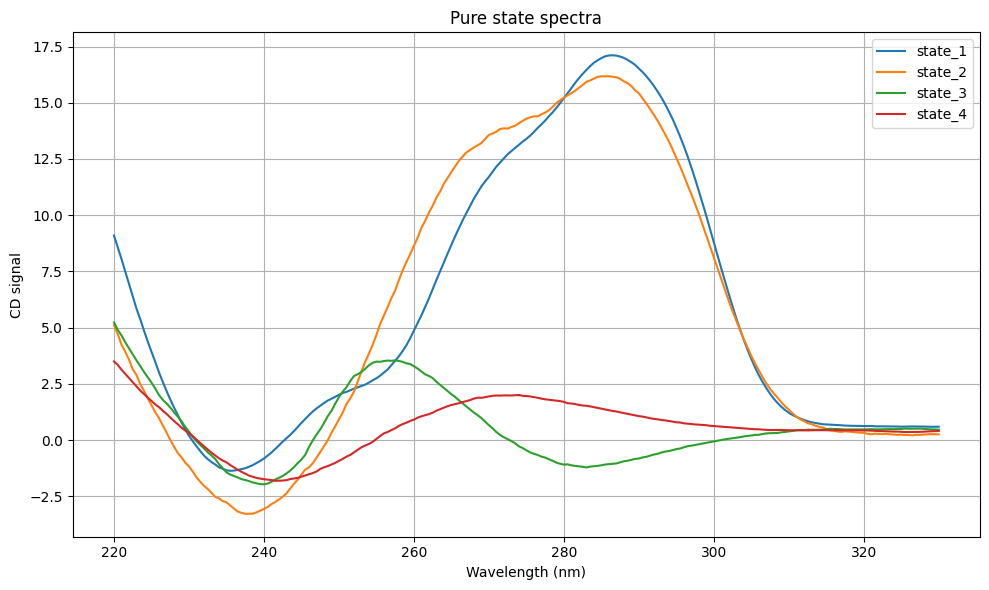

In [3]:
state_labels = {
    "state_1": "state_1",
    "state_2": "state_2",
    "state_3": "state_3",
    "state_4": "state_4",
}

plt.figure(figsize=(10, 6))

for state_name, spectrum in state_spectra.items():
    plt.plot(wavelengths, spectrum, label=state_labels.get(state_name, state_name))

plt.xlabel("Wavelength (nm)")
plt.ylabel("CD signal")
plt.title("Pure state spectra")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

M shape: (4, 41)


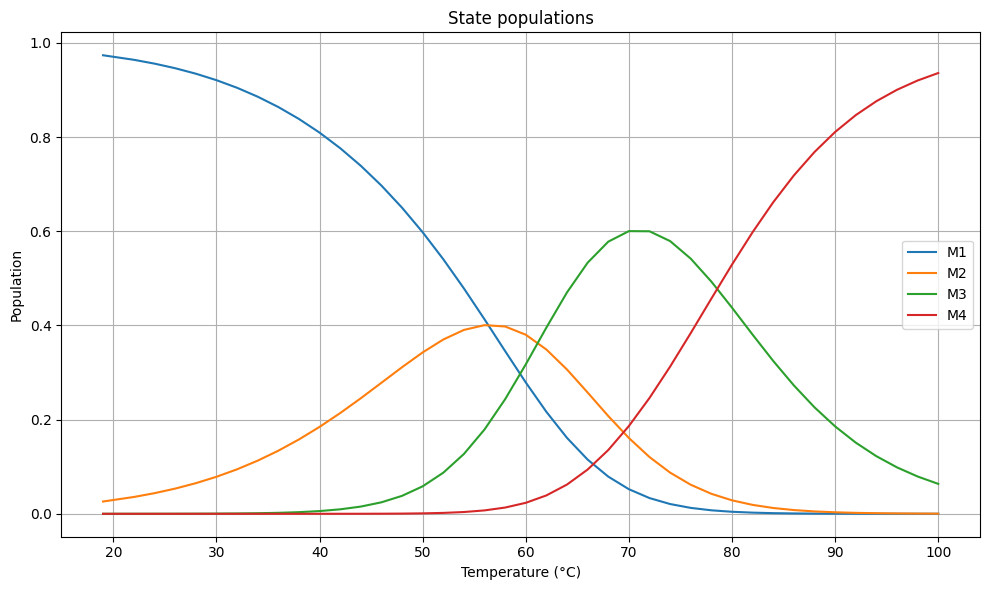

In [4]:
print("M shape:", M.shape)

plt.figure(figsize=(10, 6))

for i in range(M.shape[0]):
    plt.plot(T - 273.15, M[i], label=f"M{i+1}")

plt.xlabel("Temperature (°C)")
plt.ylabel("Population")
plt.title("State populations")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
interact(
    lambda idx: plot_reconstructed_spectrum(
        T=T,
        U_prime=U_prime,
        x_full=x_full,
        pack=pack,
        wavelengths=wavelengths,
        idx=idx,
    ),
    idx=widgets.IntSlider(min=0, max=len(T)-1, step=1)
)

interactive(children=(IntSlider(value=0, description='idx', max=40), Output()), _dom_classes=('widget-interact…

<function __main__.<lambda>(idx)>

In [6]:
interact(
    lambda idx: plot_spectrum_comparison(
        spectral_matrix=spectral_matrix,
        spectra_pred=spectra_pred,
        T=T,
        wavelengths=wavelengths,
        idx=idx,
    ),
    idx=widgets.IntSlider(min=0, max=len(T)-1, step=1)
)

interactive(children=(IntSlider(value=0, description='idx', max=40), Output()), _dom_classes=('widget-interact…

<function __main__.<lambda>(idx)>